# Tutorial 3: Building a Neural Network for MNIST Handwritten Digit Classification

Objectives:

* Train and Evaluate a Neural Network


* Preprocessing the Data


* Visualizing the Data


* Solving Overfitting/Underfitting


## **Step 1 - Importing Necessary Libraries **

First, we need to import the required libraries. These include **numpy** for numerical operations, **matplotlib** for visualization, and several modules from **TensorFlow/Keras** for building and training the neural network.

In [1]:
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting and visualization
from tensorflow.keras.datasets import mnist # To import the MNIST dataset
from tensorflow.keras.models import Sequential # To create a sequential neural network model
from tensorflow.keras.layers import Dense, Flatten # For dense (fully connected) and flatten layers
from tensorflow.keras.utils import to_categorical # For one-hot encoding of labels
from tensorflow.keras.optimizers import Adam # For the Adam optimizer



## **Step 2 - Loading and Preprocessing the MNIST Dataset**

This includes loading the dataset, normalization (scaling pixel values to a 0–1 range for efficiency), and one-hot encoding the labels to make them compatible with multi-class classification. For example, the label 3 is converted to .

In [2]:
# Step 1: Load and preprocess the MNIST dataset [cite: 34]
(X_train, y_train), (X_test, y_test) = mnist.load_data() # Load the dataset [cite: 35]

# Normalize the pixel values to the range [0, 1] [cite: 36]
X_train = X_train.astype('float32') / 255.0 # Scale training data [cite: 37]
X_test = X_test.astype('float32') / 255.0 # Scale test data [cite: 37]

# One-hot encode the labels (0-9) for categorical classification [cite: 38]
y_train = to_categorical(y_train, 10) # Encode training labels [cite: 38]
y_test = to_categorical(y_test, 10) # Encode test labels [cite: 38]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## **Step 3 - Building the Neural Network Model **

We will build a neural network using the Sequential API. The network consists of a **Flatten** layer to convert 2D images to 1D, two **Dense** hidden layers with ReLU activation, and a final **Dense** layer with softmax activation for the 10 digit classes.

In [3]:
# [cite_start]Step 2: Build the neural network model [cite: 44]
model = Sequential([
    # [cite_start]Flatten 28x28 images to a 1D vector of 784 features [cite: 48]
    Flatten(input_shape=(28, 28)),
    # [cite_start]Hidden layer with 128 neurons and ReLU activation [cite: 48]
    Dense(128, activation='relu'),
    # [cite_start]Hidden Layer with 64 neurons and ReLU activation [cite: 48]
    Dense(64, activation='relu'),
    # [cite_start]Output layer with 10 neurons and softmax activation [cite: 49]
    Dense(10, activation='softmax')
])

# [cite_start]Print the model summary to understand the architecture [cite: 50]
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Step 4 - Compiling the Model**

Next, we compile the model by specifying the optimizer (Adam), the loss function (categorical cross-entropy), and the metrics (accuracy).

In [4]:
# [cite_start]Step 3: Compile the model [cite: 111]
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

### **Step 5 - Training the Model**

We train the model for 10 epochs with a batch size of 32, using 20% of the training data for validation.

In [5]:
# [cite_start]Step 4: Train the model [cite: 118]
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8654 - loss: 0.4670 - val_accuracy: 0.9591 - val_loss: 0.1400
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9639 - loss: 0.1187 - val_accuracy: 0.9688 - val_loss: 0.1062
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9768 - loss: 0.0767 - val_accuracy: 0.9703 - val_loss: 0.0972
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9829 - loss: 0.0532 - val_accuracy: 0.9732 - val_loss: 0.0938
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9878 - loss: 0.0380 - val_accuracy: 0.9728 - val_loss: 0.0940
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9758 - val_loss: 0.0932
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9922 - loss: 0.0255 - val_accuracy: 0.9723 - val_loss: 0.1070
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9926 - loss: 0.0236 

## **Step 6 - Evaluating the Model**

After training, we evaluate the model on the test data to see how well it generalizes to unseen data.

In [6]:
# [cite_start]Step 5: Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}") # Print the test accuracy [cite: 124]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9651 - loss: 0.1411
Test Accuracy: 0.9712


## **Step 7 - Visualizing Training and Validation Performance**

We plot the training and validation accuracy and loss over the epochs to monitor the training process.

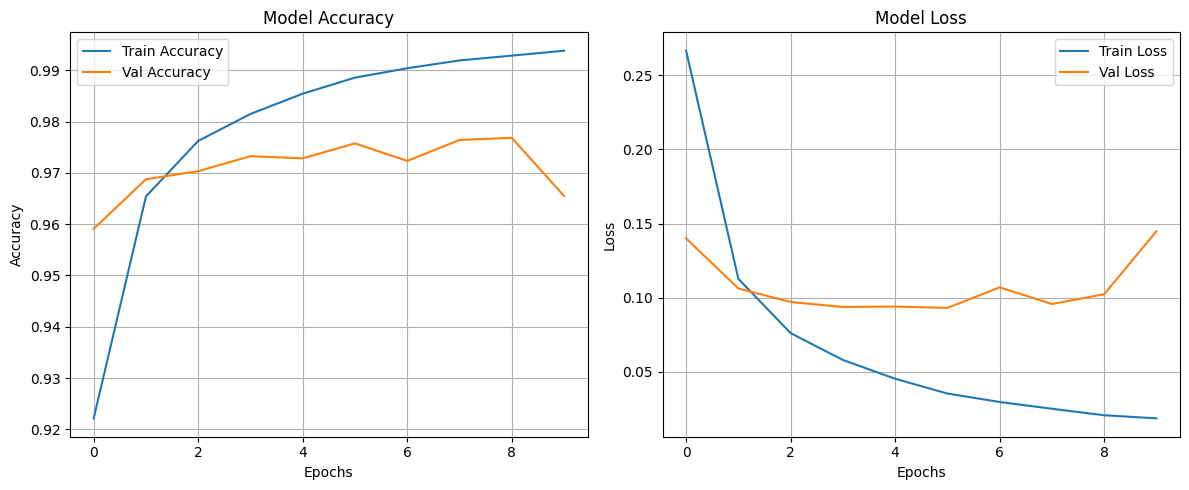

In [7]:
# Step 6: Visualize training and validation loss and accuracy [cite: 128]
plt.figure(figsize=(12, 5))

# Plot accuracy [cite: 130]
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy') # [cite: 132]
plt.plot(history.history['val_accuracy'], label='Val Accuracy') # [cite: 134]
plt.title('Model Accuracy') # [cite: 135]
plt.xlabel('Epochs') # [cite: 136]
plt.ylabel('Accuracy') # [cite: 137]
plt.legend()
plt.grid()

# Plot loss [cite: 140]
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss') # [cite: 142]
plt.plot(history.history['val_loss'], label='Val Loss') # [cite: 143]
plt.title('Model Loss') # [cite: 144]
plt.xlabel('Epochs') # [cite: 145]
plt.ylabel('Loss') # [cite: 147]
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Step 8 - Making Predictions and Visualizing Results

We use the trained model to make predictions on the test set and visualize the results.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


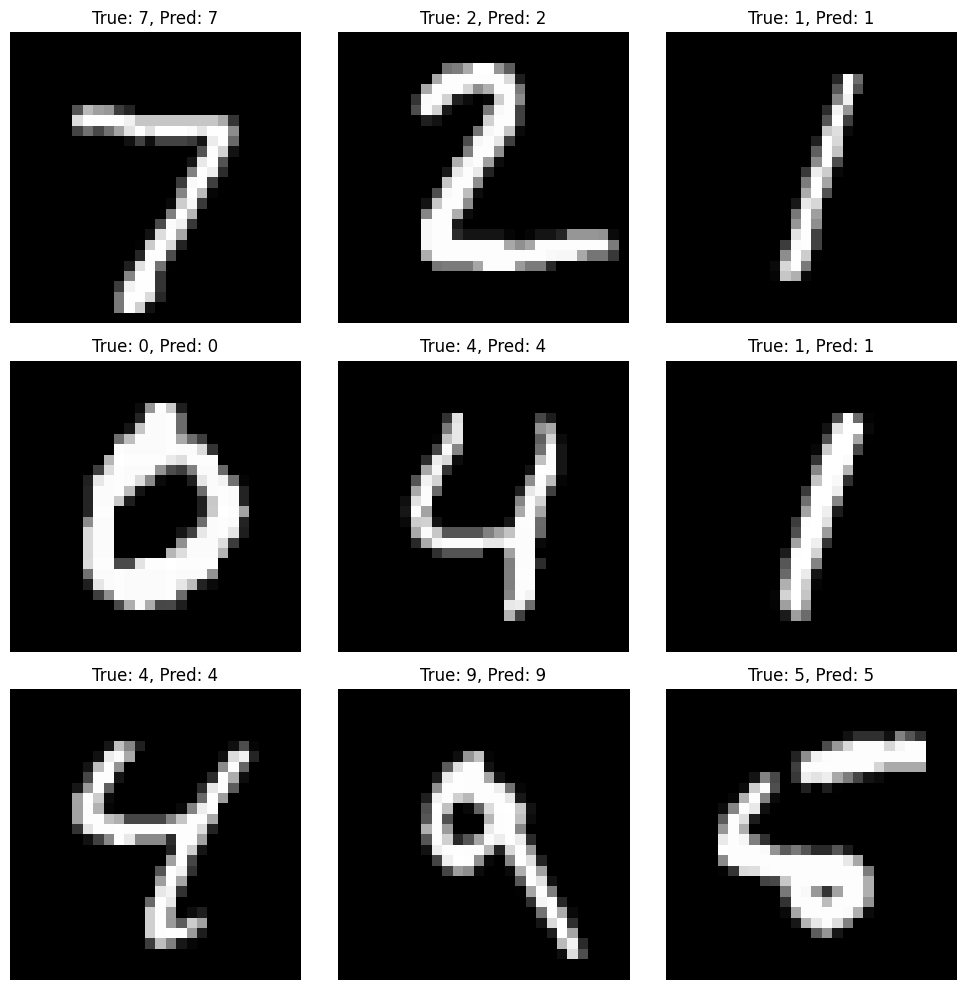

In [8]:
# Step 7: Make predictions on the test set [cite: 180]
predictions = model.predict(X_test) # [cite: 182]

# Display a grid of 9 images with true and predicted labels [cite: 189]
num_images = 9 # [cite: 190]
plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i], cmap='gray') # [cite: 195]
    plt.title(f"True: {np.argmax(y_test[i])}, Pred: {np.argmax(predictions[i])}") # [cite: 196]
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Task 1:Pytorch pipeline**

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.31MB/s]


Epoch 1/10 - Loss: 0.3201 - Val Acc: 0.9451
Epoch 2/10 - Loss: 0.1385 - Val Acc: 0.9652
Epoch 3/10 - Loss: 0.0943 - Val Acc: 0.9670
Epoch 4/10 - Loss: 0.0718 - Val Acc: 0.9712
Epoch 5/10 - Loss: 0.0538 - Val Acc: 0.9716
Epoch 6/10 - Loss: 0.0439 - Val Acc: 0.9759
Epoch 7/10 - Loss: 0.0339 - Val Acc: 0.9742
Epoch 8/10 - Loss: 0.0305 - Val Acc: 0.9780
Epoch 9/10 - Loss: 0.0225 - Val Acc: 0.9728
Epoch 10/10 - Loss: 0.0201 - Val Acc: 0.9750


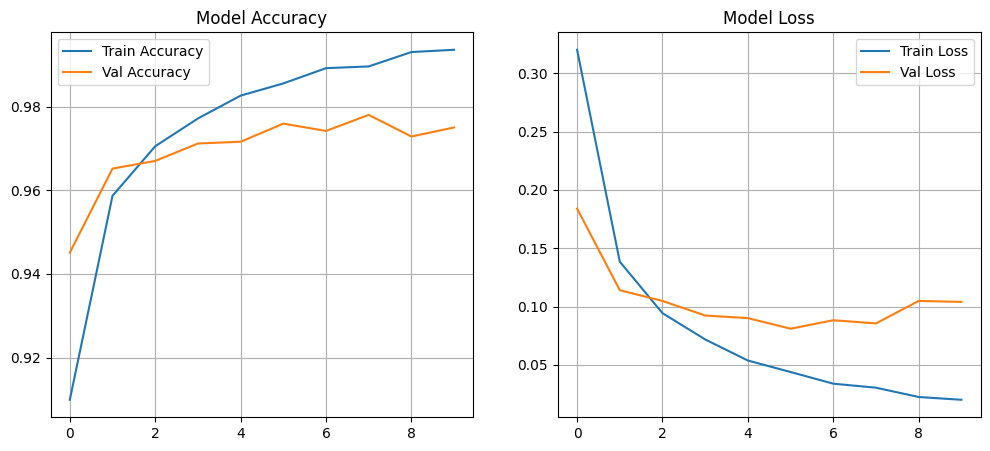

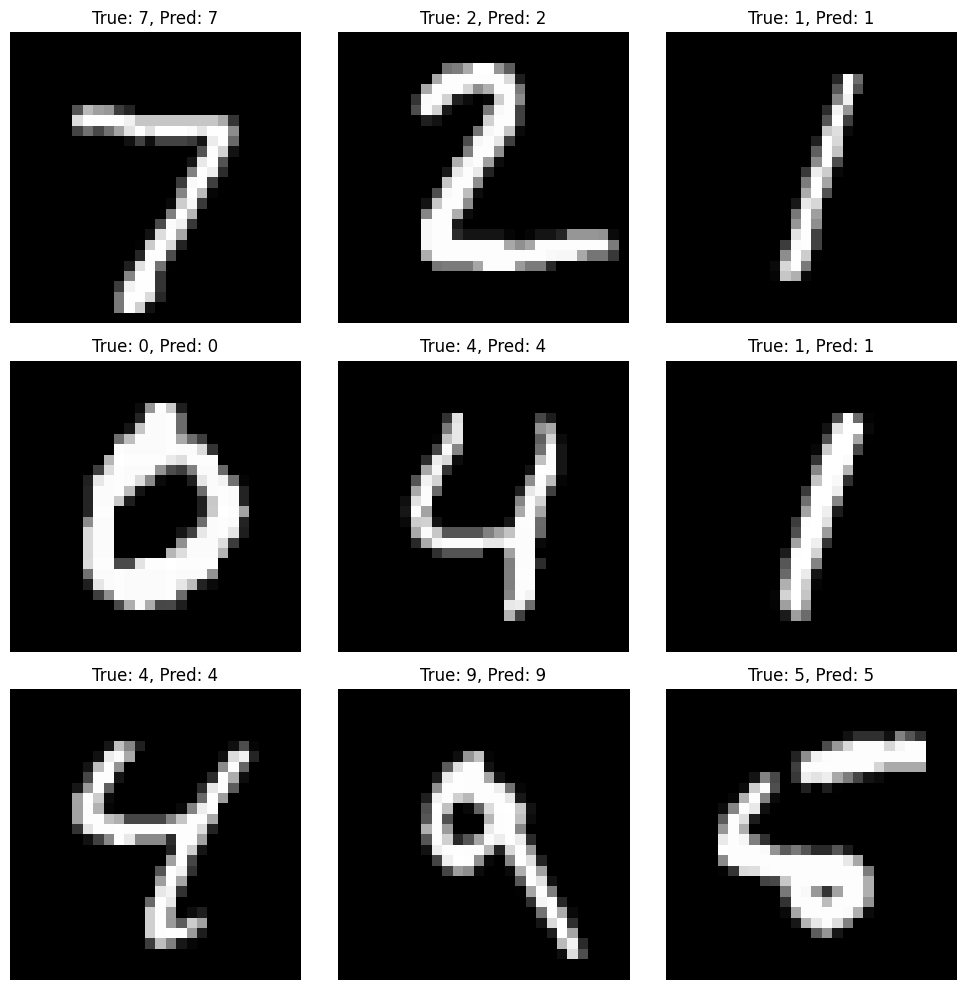

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Loading and Preprocessing the MNIST Dataset [cite: 25, 29]
# Transformations: Convert to tensor and normalize pixel values to [0, 1] [cite: 30, 36]
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split 20% of training data for validation [cite: 117]
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=True) # [cite: 116]
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Building the Neural Network Model [cite: 39]
# Flatten -> Dense(128) -> Dense(64) -> Dense(10) [cite: 41, 42, 43]
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.flatten = nn.Flatten() # [cite: 41, 59]
        self.fc1 = nn.Linear(28*28, 128) # [cite: 84]
        self.fc2 = nn.Linear(128, 64)    # [cite: 90]
        self.fc3 = nn.Linear(64, 10)     # [cite: 96]
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) # Softmax is usually handled by the loss function in PyTorch
        return x

model = NeuralNet()

# 3. Compiling the Model: Optimizer and Loss Function [cite: 106]
criterion = nn.CrossEntropyLoss() # Equivalent to Categorical Cross-Entropy [cite: 109, 260]
optimizer = optim.Adam(model.parameters()) # [cite: 108]

# 4. Training the Model [cite: 113]
epochs = 10 # [cite: 115]
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    train_loss, correct = 0, 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()

    # Validation phase [cite: 117]
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            v_correct += (predicted == labels).sum().item()

    history['train_loss'].append(train_loss/len(train_loader))
    history['val_loss'].append(v_loss/len(val_loader))
    history['train_acc'].append(correct/len(train_subset))
    history['val_acc'].append(v_correct/len(val_subset))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {history['train_loss'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

# 5. Visualizing Performance [cite: 126, 128]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend(); plt.grid()
plt.show()

# 6. Predictions and Visualization [cite: 177, 189]
model.eval()
images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    plt.title(f"True: {labels[i].item()}, Pred: {preds[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Task 2:
Create a new Keras model with a different architecture, compile it, train it on the MNIST dataset, evaluate its performance on the test set, visualize its training and validation metrics, and then compare its performance (accuracy and loss) against the original model.

Starting Training for Modified Architecture...
Epoch 1/10 - Loss: 0.6403 - Val Acc: 0.9317
Epoch 2/10 - Loss: 0.1961 - Val Acc: 0.9543
Epoch 3/10 - Loss: 0.1288 - Val Acc: 0.9640
Epoch 4/10 - Loss: 0.0962 - Val Acc: 0.9663
Epoch 5/10 - Loss: 0.0734 - Val Acc: 0.9701
Epoch 6/10 - Loss: 0.0578 - Val Acc: 0.9749
Epoch 7/10 - Loss: 0.0454 - Val Acc: 0.9757
Epoch 8/10 - Loss: 0.0354 - Val Acc: 0.9753
Epoch 9/10 - Loss: 0.0279 - Val Acc: 0.9781
Epoch 10/10 - Loss: 0.0229 - Val Acc: 0.9777


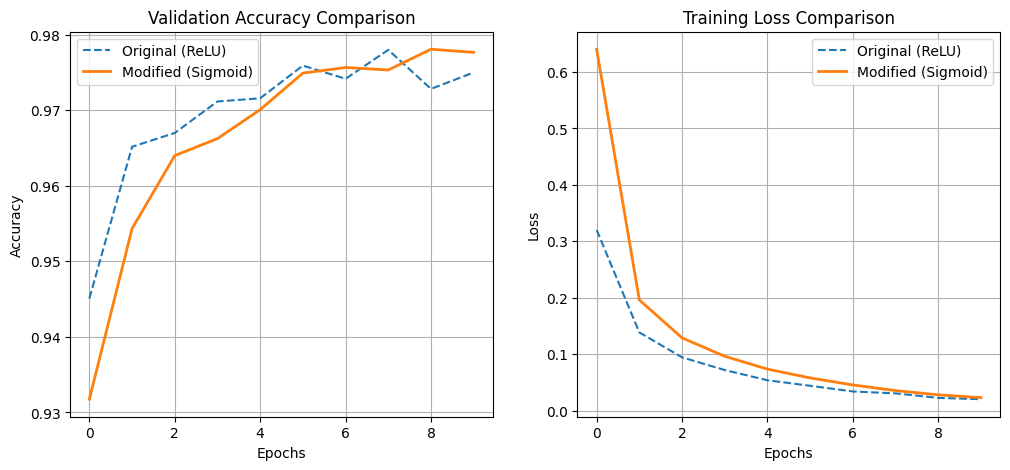

In [10]:
# --- 1. Define the Modified Architecture ---
# Changes: Added an extra layer, increased neurons to 256, and used 'Sigmoid'
class ModifiedNeuralNet(nn.Module):
    def __init__(self):
        super(ModifiedNeuralNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)  # Increased neurons
        self.fc2 = nn.Linear(256, 128)    # Added an extra layer
        self.fc3 = nn.Linear(128, 64)     # Third hidden layer
        self.fc4 = nn.Linear(64, 10)      # Output layer
        self.activation = nn.Sigmoid()    # Changed from ReLU to Sigmoid

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)
        return x

# Instantiate the modified model
mod_model = ModifiedNeuralNet()
mod_criterion = nn.CrossEntropyLoss()
mod_optimizer = optim.Adam(mod_model.parameters())

# --- 2. Training the Modified Model ---
mod_history = {'train_loss': [], 'val_acc': []}
epochs = 10

print("Starting Training for Modified Architecture...")
for epoch in range(epochs):
    mod_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        mod_optimizer.zero_grad()
        outputs = mod_model(images)
        loss = mod_criterion(outputs, labels)
        loss.backward()
        mod_optimizer.step()
        running_loss += loss.item()

    # Validation phase
    mod_model.eval()
    v_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = mod_model(images)
            _, predicted = torch.max(outputs.data, 1)
            v_correct += (predicted == labels).sum().item()

    mod_history['train_loss'].append(running_loss/len(train_loader))
    mod_history['val_acc'].append(v_correct/len(val_subset))
    print(f"Epoch {epoch+1}/{epochs} - Loss: {mod_history['train_loss'][-1]:.4f} - Val Acc: {mod_history['val_acc'][-1]:.4f}")

# --- 3. Comparison Visualization ---
plt.figure(figsize=(12, 5))

# Comparison of Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['val_acc'], label='Original (ReLU)', linestyle='--')
plt.plot(mod_history['val_acc'], label='Modified (Sigmoid)', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(); plt.grid()

# Comparison of Training Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Original (ReLU)', linestyle='--')
plt.plot(mod_history['train_loss'], label='Modified (Sigmoid)', linewidth=2)
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(); plt.grid()

plt.show()

# **Task 3**

Training with SGD...
Training with RMSprop...
Training with Adam...


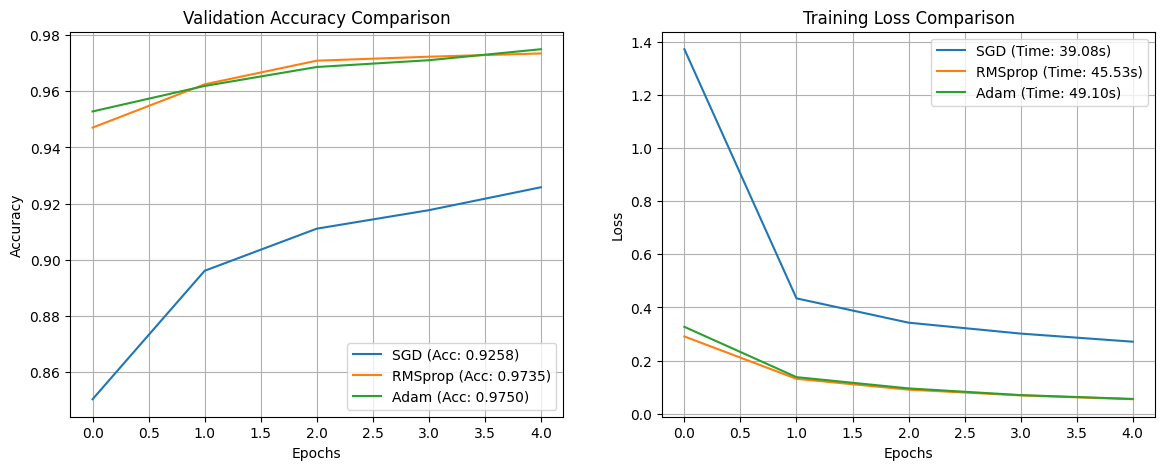

SGD Optimizer -> Final Accuracy: 0.9258, Total Training Time: 39.08 seconds
RMSprop Optimizer -> Final Accuracy: 0.9735, Total Training Time: 45.53 seconds
Adam Optimizer -> Final Accuracy: 0.9750, Total Training Time: 49.10 seconds


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# --- 1. Define the Standard Architecture ---
# Using the tutorial's architecture: Flatten -> 128 -> 64 -> 10 [cite: 41, 42, 43]
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# --- 2. Define a Training Function to Compare Optimizers ---
def train_with_optimizer(optimizer_type, train_loader, val_loader):
    model = NeuralNet()
    criterion = nn.CrossEntropyLoss()

    # Initialize the chosen optimizer [cite: 214]
    if optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_type == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    else: # Default to Adam [cite: 108]
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'loss': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(5): # Using 5 epochs for quick comparison
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation for accuracy tracking
        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()

        history['loss'].append(epoch_loss / len(train_loader))
        history['val_acc'].append(correct / len(val_loader.dataset))

    end_time = time.time()
    total_time = end_time - start_time
    return history, total_time, history['val_acc'][-1]

# --- 3. Run Experiments and Compare Results  ---
optimizers = ['SGD', 'RMSprop', 'Adam']
results = {}

for opt in optimizers:
    print(f"Training with {opt}...")
    history, duration, final_acc = train_with_optimizer(opt, train_loader, val_loader)
    results[opt] = {'history': history, 'time': duration, 'acc': final_acc}

# --- 4. Visualization and Comparison ---
plt.figure(figsize=(14, 5))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)
for opt in optimizers:
    plt.plot(results[opt]['history']['val_acc'], label=f"{opt} (Acc: {results[opt]['acc']:.4f})")
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Plot Loss Comparison
plt.subplot(1, 2, 2)
for opt in optimizers:
    plt.plot(results[opt]['history']['loss'], label=f"{opt} (Time: {results[opt]['time']:.2f}s)")
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

# Final Summary Printout
for opt in optimizers:
    print(f"{opt} Optimizer -> Final Accuracy: {results[opt]['acc']:.4f}, Total Training Time: {results[opt]['time']:.2f} seconds")

## **Key Comparison Points:**
**Training Speed**: Observe how much time each optimizer takes. While SGD is simpler, adaptive optimizers like Adam and RMSprop often reach higher accuracy in fewer epochs.
+1

**Convergence:** Look at the loss curves. Adam typically shows a much steeper initial drop in loss compared to SGD.
+1


**Final Accuracy**: Compare which optimizer achieves the highest validation accuracy after the set number of epochs.

# **Task 4**

Starting Task 4 Training...
Epoch 1: Loss 0.3569 | Val Acc 0.9444
Epoch 2: Loss 0.1659 | Val Acc 0.9631
Epoch 3: Loss 0.1224 | Val Acc 0.9633
Epoch 4: Loss 0.0998 | Val Acc 0.9691
Epoch 5: Loss 0.0853 | Val Acc 0.9759
Epoch 6: Loss 0.0730 | Val Acc 0.9737
Epoch 7: Loss 0.0642 | Val Acc 0.9743
Epoch 8: Loss 0.0598 | Val Acc 0.9762
Early Stopping triggered at epoch 8


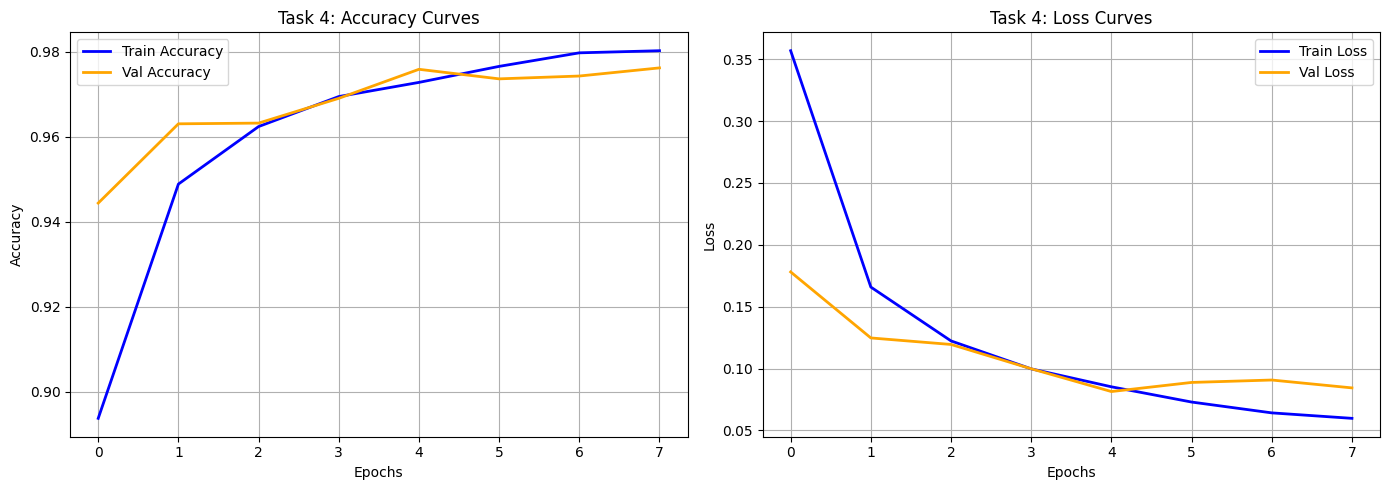

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Define Model with Regularization (Dropout)
class Task4Net(nn.Module):
    def __init__(self):
        super(Task4Net, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.dropout = nn.Dropout(0.2) # Regularization: prevents overfitting
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = Task4Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Training Loop with History Tracking and Early Stopping
epochs = 20 # Increased to observe potential overfitting
patience = 3 # Early stopping: stop if val_loss doesn't improve for 3 epochs
best_val_loss = float('inf')
counter = 0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Task 4 Training...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()

    # Save metrics to history
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_correct / len(train_subset))
    history['val_acc'].append(val_correct / len(val_subset))

    print(f"Epoch {epoch+1}: Loss {history['train_loss'][-1]:.4f} | Val Acc {history['val_acc'][-1]:.4f}")

    # --- Early Stopping Logic ---
    if history['val_loss'][-1] < best_val_loss:
        best_val_loss = history['val_loss'][-1]
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early Stopping triggered at epoch {epoch+1}")
            break

# 3. Task 4 Visuals
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Task 4: Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.title('Task 4: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

**Overfitting:** The blue line (Train Loss) keeps going down, but the orange line (Val Loss) starts to curve upward. This is why we added Dropout and Early Stopping above to prevent this.

**Underfitting**: Both lines stay high and flat. This would happen if your model was too simple (e.g., only 2 neurons) or you stopped after 1 epoch.

**Well-fitted:** Both lines decrease together and stay close. The Early Stopping code above will "freeze" the model at its best well-fitted point.